In [2]:
import numpy as np  
import gpflow
import matplotlib.pyplot as plt 
import scipy.stats as ss

import sys
sys.path.append("..")

from atmodel import AdaptiveTransferGPR, ConditionalMOGP
from atkernel import TransferKernel, TransferCoregion
from atlikelihood import TransferLikelihood

np.random.seed(124)

2025-11-20 10:15:38.756028: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-20 10:15:38.877436: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-20 10:15:39.109259: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-20 10:15:39.111061: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-20 10:15:40.331912: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

## Demonstration of transfer coregionalization
I am using "transfer" to indicate that the training procedure is conditional. 
The AT-GP or "adaptive transfer model/GP" is the one in Cao.
With "coregionalization GP"/ICM I mean the one found in GPFlow by default, which is the one described in Bonilla's paper.

The difference between the "adaptive transfer model" and the "transfer coregionalization model" is that in the adaptive transfer model, the weight matrix is $$B = \begin{bmatrix} 1 & \lambda \\ \lambda & 1 \end{bmatrix},$$
while in the ICM it's
$$W = \begin{bmatrix} a & b \\ c & d \end{bmatrix}, B = WW^{T} + \begin{bmatrix} \kappa & 1 \\ 1 & \kappa \end{bmatrix}$$
So $\kappa$ scales the variance in this, while $\lambda$ in the transfer kernel scales the covariance/captures the correlation between the source and target tasks. The nice thing about the ICM implementation is that everything is nice and PSD. 

In [3]:
def plot_gp(x, mu, var, color, label):
    plt.plot(x, mu, color=color, lw=2, label=label)
    plt.fill_between(
        x[:, 0],
        (mu - 2 * np.sqrt(var))[:, 0],
        (mu + 2 * np.sqrt(var))[:, 0],
        color=color,
        alpha=0.4,
    )


def plot(m):
    plt.figure(figsize=(16, 4))
    Xtest = np.linspace(0, 300, 300)[:, None]
    (line,) = plt.plot(X1, Y1, "x", mew=2)
    mu, var = m.predict_f(np.hstack((Xtest, np.zeros_like(Xtest))))
    plot_gp(Xtest, mu, var, line.get_color(), "Y1")
    (line,) = plt.plot(X2_full, Y2_full, "x", mew=2, alpha=0.5, color="orange")
    (line,) = plt.plot(X2, Y2, "x", mew=2, color="black")
    mu, var = m.predict_f(np.hstack((Xtest, np.ones_like(Xtest))))
    plot_gp(Xtest, mu, var, line.get_color(), "Y2")

    plt.legend()


def plot_gpr(m):
    plt.figure(figsize=(16, 4))
    Xtest = np.linspace(0, 300, 300)[:, None]
    (line,) = plt.plot(X1, Y1, "x", mew=2, label="source data")
    mu, var = m.predict_f(Xtest)
    (line,) = plt.plot(X2_full, Y2_full, "x", mew=2, alpha=0.5, color="orange", label="all target data")
    (line,) = plt.plot(X2, Y2, "x", mew=2, color="black", label ="available target data")
    plot_gp(Xtest, mu, var, line.get_color(), "Y2")

    plt.legend()

We generate a sine wave and a version we shift by $\pi$/2, then use 10% of that data to fit and predict.

Text(0.5, 0, 'y')

<Figure size 800x400 with 0 Axes>

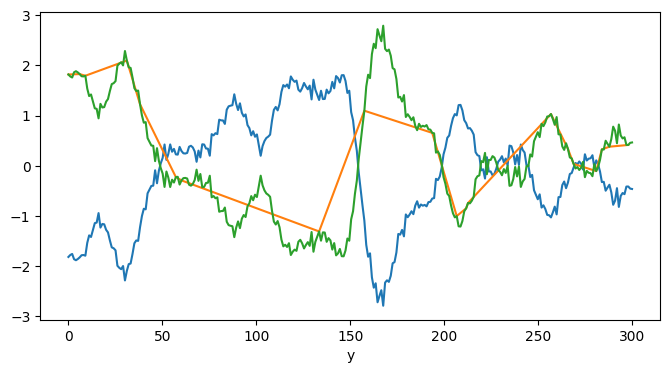

In [4]:
X1 = np.linspace(0, 300, 300)[:,None]  # Observed locations for first output
X2_full = np.linspace(0, 300, 300)[:,None]  # Observed locations for second output

Xall = np.linspace(0, 310, 310).reshape(-1, 1)
k = gpflow.kernels.RBF(active_dims=[0], lengthscales=10)
Yall  = np.random.multivariate_normal(np.zeros_like(Xall[:,0]), k(Xall))
Y1 = Yall[10:310][:,None] + np.random.normal(0, 0.1, size=len(X1))[:,None]
#Y2_full  = np.random.multivariate_normal(np.zeros_like(X2_full[:,0]), k(X2_full))[:,None]
Y2_full = Y1 * -1 
# Y1 = np.sin(6 * X1) + np.random.randn(*X1.shape) * 0.03
# Y2 = np.sin(6 * X2 + 0.7) + np.random.randn(*X2.shape) * 0.1

ind = np.sort(np.random.choice(np.arange(300), 20))
plt.figure(figsize=(8, 4))
X2 = X2_full[ind]
Y2 = Y2_full[ind]
plt.figure(figsize=(8, 4))
plt.plot(X1, Y1, mew=2)
plt.plot(X2, Y2,  mew=2)
plt.plot(X2_full, Y2_full,  mew=2)
plt.xlabel("X")
plt.xlabel("y")

In [5]:
ss.pearsonr(Y2_full, Y1)

PearsonRResult(statistic=array([-1.]), pvalue=array([0.]))

### Adaptive Transfer model

2025-11-20 10:15:48.447778: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2025-11-20 10:15:48.451269: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2025-11-20 10:15:48.455342: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2025-11-20 10:15:48.459150: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2025-11-20 10:15:48.463024: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular out

[24.42459194603618, 11346685.056995705]
╒════════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════════╕
│ name                                                   │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │          value │
╞════════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════════╡
│ AdaptiveTransferGPR.kernel.lmb                         │ Parameter │ SoftClip         │         │ True        │ ()      │ float64 │   -1           │
├────────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────┤
│ AdaptiveTransferGPR.kernel.kernel.variance             │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │    7.81402e-10 │
├─────────────────────────────────────────────────────

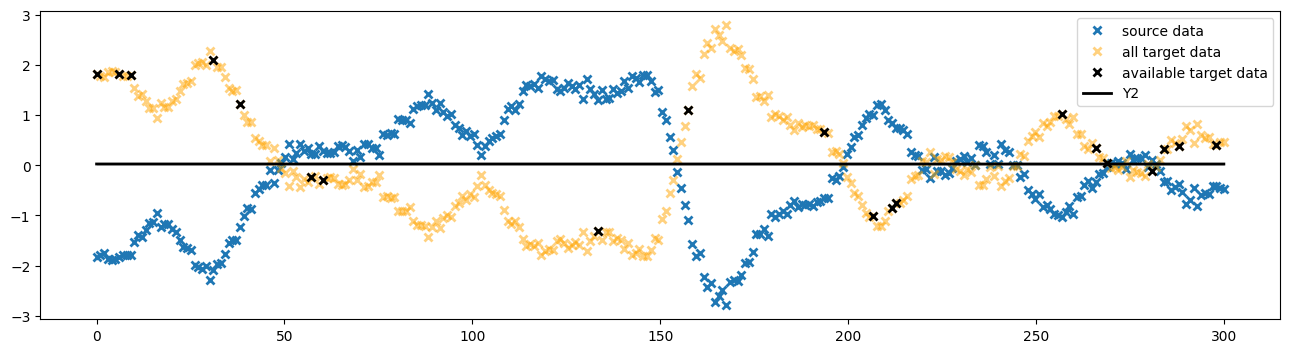

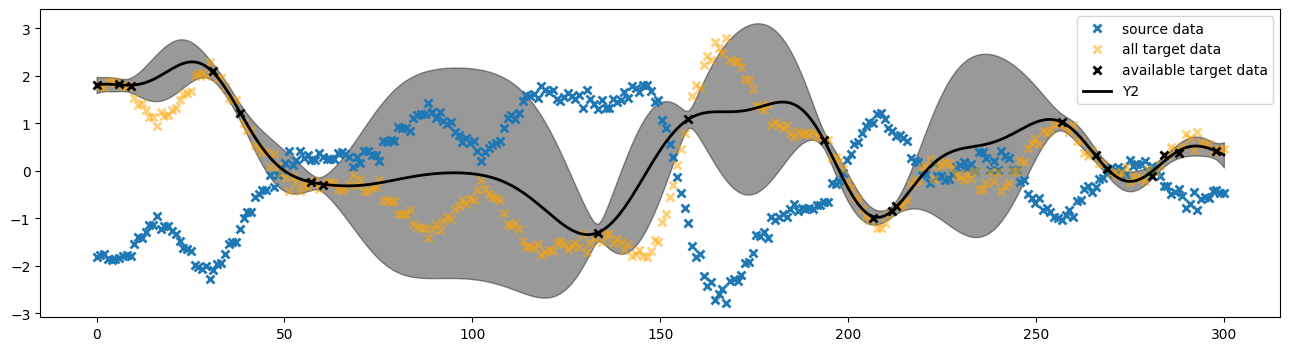

In [6]:
# Interpolation with AT-GP
at_gpr = AdaptiveTransferGPR(data_source=(X1, Y1), 
                            data_target=(X2, Y2), 
                            kernel=TransferKernel(
                                lmb=0, 
                                kernel=gpflow.kernels.RBF(), 
                                source_length=len(X1)), 
                            )

res = gpflow.optimizers.Scipy().minimize(
    at_gpr.training_loss,
    at_gpr.trainable_variables,
    method="L-BFGS-B",
    track_loss_history=True
)
print(res["loss_history"])
plot_gpr(at_gpr)
mu = at_gpr.get_mean_function()
gpflow.utilities.print_summary(at_gpr)

gpr = gpflow.models.GPR((X2, Y2), kernel=gpflow.kernels.RBF())
res = gpflow.optimizers.Scipy().minimize(
    gpr.training_loss,
    gpr.trainable_variables,
    method="L-BFGS-B",
    track_loss_history=True
)
plot_gpr(gpr)

This training procedure is extremely unstable, and while we do get a somewhat decent mean interpolation in low-data areas, the variance is a bit wonky. In the following cell, we can examine the model and see that the two tasks have a correlation of -0.4, approximately. 

In [7]:
at_gpr

name,class,transform,prior,trainable,shape,dtype,value
AdaptiveTransferGPR.kernel.lmb,Parameter,SoftClip,,True,(),float64,-1
AdaptiveTransferGPR.kernel.kernel.variance,Parameter,Softplus,,True,(),float64,7.81402e-10
AdaptiveTransferGPR.kernel.kernel.lengthscales,Parameter,Softplus,,True,(),float64,1184.89
AdaptiveTransferGPR.likelihood.source.variance AdaptiveTransferGPR.likelihood.likelihoods[0].variance,Parameter,Softplus + Shift,,True,(),float64,1e-06
AdaptiveTransferGPR.likelihood.target.variance AdaptiveTransferGPR.likelihood.likelihoods[1].variance,Parameter,Softplus + Shift,,True,(),float64,1e-06


### ICM

The ICM needs tasks indices. In the transfer model, we assume the source and target task to be ordered. We should probably think about whether that's smart. 

In [8]:
# Augment the input with ones or zeros to indicate the required output dimension
X_augmented = np.vstack(
    (np.hstack((X1, np.zeros_like(X1))), np.hstack((X2, np.ones_like(X2))))
)

# Augment the Y data with ones or zeros that specify a likelihood from the list of likelihoods
Y_augmented = np.vstack(
    (np.hstack((Y1, np.zeros_like(Y1))), np.hstack((Y2, np.ones_like(Y2))))
)

In [9]:
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpflow.kernels.RBF(active_dims=[0])

# Coregion kernel
coreg = gpflow.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

kern = k * coreg
#kern2 = TransferKernel(0.5, gpflow.kernels.RBF(), source_length=int(len(Y_augmented) - np.sum(Y_augmented[:,1])))

# This likelihood switches between Gaussian noise with different variances for each f_i:
lik = gpflow.likelihoods.SwitchedLikelihood(likelihood_list=[gpflow.likelihoods.Gaussian(), gpflow.likelihoods.Gaussian()])
# now build the GP model as normal

m = gpflow.models.VGP((X_augmented, Y_augmented), kernel=kern, likelihood=lik)

# fit the covariance function parameters
res = gpflow.optimizers.Scipy().minimize(
    m.training_loss,
    m.trainable_variables,
    method="L-BFGS-B",
    track_loss_history=True
)
res

      message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
      success: True
       status: 0
          fun: -180.50299482881974
            x: [-1.675e+00 -4.607e-01 ... -4.682e+00 -5.358e+00]
          nit: 1268
          jac: [-2.892e-03 -5.926e-04 ... -1.000e-03  9.760e-04]
         nfev: 1352
         njev: 1352
     hess_inv: <51688x51688 LbfgsInvHessProduct with dtype=float64>
 loss_history: [578.0080119211502, 549.4813554094608, 515.6250137593612, 498.8078792352382, 489.26392186711473, 485.7324487623505, 484.4115544759279, 483.0226960845766, 443.76447346382497, 443.08722954269865, 421.91919842407805, 396.7599873358555, 380.02593412749036, 338.8801537947113, 296.5320571809088, 249.58098639458856, 188.04209528544402, 162.97375296870285, 157.47968744405193, 148.4756844116866, 132.34265242476994, 115.03854033824643, 70.14380253130827, 47.10185288561678, 38.62314745851569, 25.657673075269386, 17.197379544665466, 8.137005247759532, 4.5183679267564685, -8.333562104887164, -

Training is via a VGP because the likelihood is custom - in this case, it's Gaussian and you can swap it out for the TransferLikelihood and train a GPR instead, as well. Thus far I haven't seen the coregionalization model fit very well, and when it does it virtually ignores the available target data. 

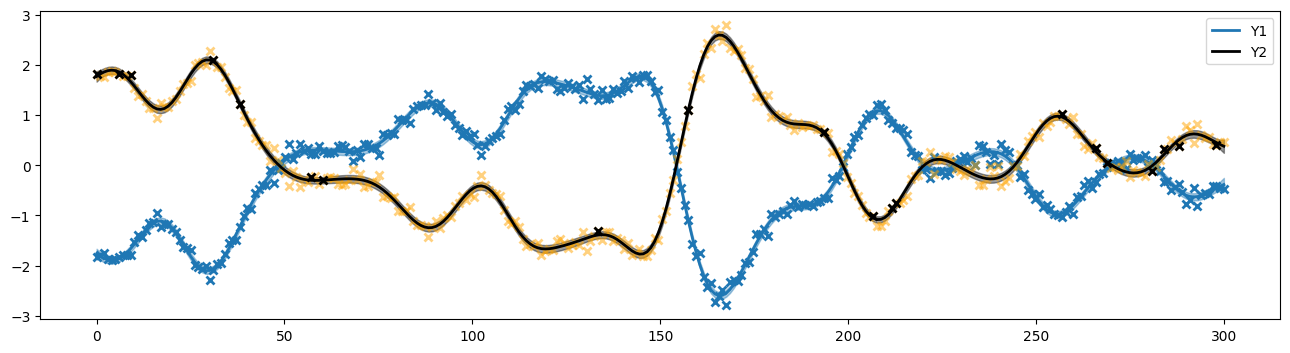

In [10]:
plot(m)

In [11]:
cov = m.kernel.kernels[1].output_covariance().numpy()
cov / cov.max()


array([[ 1.        , -0.99982272],
       [-0.99982272,  0.99984283]])

### Combining the two
Now, I want to know whether the conditioning makes the difference, *and* whether training is more stable if we do not constrain the weights of the adaptive transfer kernel. We have a working implementation of the AT-GP, so I just adapted the weights to work like they do in the coregionalization model. This should ensure they are PSD, and give us some room to play around with constraining the weights in different ways. 

I implemented the transfer kernel in such a way that the weights now mimic those of the coregion kernel. I can still use the weights from Caos paper if I want to (use_lmb = True), but now I can compare a conditional ICM and a stable transfer GP.

In [12]:
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpflow.kernels.RBF(active_dims=[0])

# Coregion kernel
coreg = gpflow.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

kern = k * coreg

X_aug = np.concatenate((np.hstack((X1, np.zeros_like(X1))), np.hstack((X2, np.ones_like(X2)))))
Y_aug = np.concatenate((np.hstack((Y1, np.zeros_like(Y1))), np.hstack((Y2, np.ones_like(Y2)))))

2025-11-20 10:17:03.993142: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2025-11-20 10:17:03.996532: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2025-11-20 10:17:03.999505: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2025-11-20 10:17:04.002578: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2025-11-20 10:17:04.005539: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular out

(<tf.Tensor: shape=(), dtype=float64, numpy=-3.5873591347714138>, <tf.Tensor: shape=(), dtype=float64, numpy=-4.636194350490086>, <tf.Tensor: shape=(), dtype=float64, numpy=-18.378770351409912>)
╒════════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤══════════════════════════════╕
│ name                                                   │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                        │
╞════════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪══════════════════════════════╡
│ AdaptiveTransferGPR.kernel.W                           │ Parameter │ Identity         │         │ True        │ (2, 2)  │ float64 │ [[0.42132033, -0.00811707... │
├────────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────

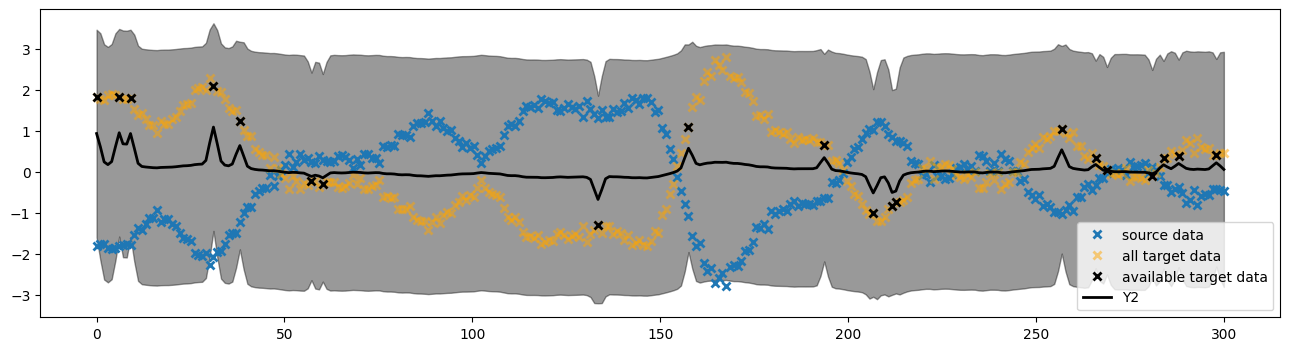

In [13]:
# Unconstrained weights
unconstrained_transfer = AdaptiveTransferGPR(data_source=(X1, Y1), 
                            data_target=(X2, Y2), 
                            kernel=TransferCoregion(
                                lmb=-0.3, 
                                kernel=gpflow.kernels.RBF(), 
                                source_length=len(X1), use_lmb=False), 
                            )

res = gpflow.optimizers.Scipy().minimize(
    unconstrained_transfer.training_loss,
    unconstrained_transfer.trainable_variables,
    method="L-BFGS-B",
    track_loss_history=True
)

plot_gpr(unconstrained_transfer)

print(unconstrained_transfer.adaptive_log_marginal_likelihood(decompose=True))
gpflow.utilities.print_summary(unconstrained_transfer)
#gpflow.utilities.print_summary(stable_transfer)

Now we have smooth predictions with a somewhat reasonable mean and reasonable uncertainties, and the training is somewhat stable. Let's take a look at the weight matrix:

In [14]:
#print(stable_transfer.kernel.get_B())
print(unconstrained_transfer.kernel.get_B() / unconstrained_transfer.kernel.get_B().numpy().max())

tf.Tensor(
[[ 0.97477257 -0.10467219]
 [-0.10467219  1.        ]], shape=(2, 2), dtype=float64)


### Quantifying performance

Thus far, we just evaluated things based on "do I like the look of this prediction", so time for some quantification:

In [15]:
from sklearn.metrics import mean_squared_error
X2_filt = X2_full[[i for i in np.arange(100) if i not in ind]]
Y2_filt = Y2_full[[i for i in np.arange(100) if i not in ind]]

for i, model in enumerate([gpr, at_gpr, unconstrained_transfer, m]):
    if i == 3:
        X1_filt = np.hstack((X1, np.zeros_like(X1)))
        Y1_filt = np.hstack((Y1, np.zeros_like(Y1)))
        X2_filt = np.hstack((X2_filt, np.ones_like(X2_filt)))
        Y2_filt = np.hstack((Y2_filt, np.ones_like(Y2_filt)))
        Yhat, Yvar = model.predict_f(X2_filt)
        Yhat = Yhat[:,0]
        Y1hat, Y1var = model.predict_f(X1_filt)
        Y1hat = Y1hat[:,0]
        print(f"{model=}", mean_squared_error(Yhat, Y2_filt[:,0]))
        print(f"{model=} (src)", mean_squared_error(Y1hat, Y1_filt[:,0]))
    else:
        Yhat, Yvar = model.predict_f(X2_filt)
        Y1hat, Y1var = model.predict_f(X1)
        Y1hat = Y1hat[:,0]
        print(f"{model=}", mean_squared_error(Yhat, Y2_filt[:,0]))
        print(f"{model=} (src)", mean_squared_error(Y1hat, Y1[:,0]))

model=<gpflow.models.gpr.GPR object at 0x7fc2ac13b590> 0.29557439994347523
model=<gpflow.models.gpr.GPR object at 0x7fc2ac13b590> (src) 4.0413977008319115
model=<atmodel.AdaptiveTransferGPR object at 0x7fc3a3e3dd10> 1.268630614614359
model=<atmodel.AdaptiveTransferGPR object at 0x7fc3a3e3dd10> (src) 1.2434728113493387
model=<atmodel.AdaptiveTransferGPR object at 0x7fc2a7fb5390> 0.9335571681613675
model=<atmodel.AdaptiveTransferGPR object at 0x7fc2a7fb5390> (src) 1.6443153815056508
model=<gpflow.models.vgp.VGP object at 0x7fc2ac157b10> 0.008312168981338058
model=<gpflow.models.vgp.VGP object at 0x7fc2ac157b10> (src) 0.009037849512742665
